In [3]:
from utils import pr
from utils import measure_time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
users = pd.DataFrame({
    "user_id": ["001", "002", "003", "004"],
    "signup_date": pd.to_datetime([
        "2023-01-01","2023-01-05","2023-01-10","2023-01-15"
    ]),
    "churned": [False, True, False, True]
})

transactions = pd.DataFrame({
    "user_id": ["001","001","002","003","003","004"],
    "transaction_date": pd.to_datetime([
        "2023-01-03","2023-02-10","2023-01-06",
        "2023-01-12","2023-03-01","2023-02-20"
    ]),
    "amount": [100,500,50,200,1000,300]
})

In [5]:

# shared x values
x = np.array([
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11
])

# dataset 1 — clear linear pattern
y1 = np.array([
    3.4, 4.1, 4.6, 5.0, 5.6, 6.1, 6.6, 7.0, 7.6, 8.0, 8.5
])

# dataset 2 — curved relationship
y2 = np.array([
    9.0, 7.8, 6.9, 6.1, 5.5, 5.2, 5.5, 6.1, 6.9, 7.8, 9.0
])

# dataset 3 — mostly linear with one strong outlier
y3 = np.array([
    3.4, 4.1, 4.6, 5.0, 5.6, 6.1, 6.6, 7.0, 7.6, 11.8, 8.5
])

# dataset 4 — clustered values + one leverage point
y4 = np.array([
    6.9, 7.1, 7.0, 6.8, 7.2, 7.1, 6.9, 7.0, 7.1, 7.0, 11.9
])

datasets = [y1, y2, y3, y4]

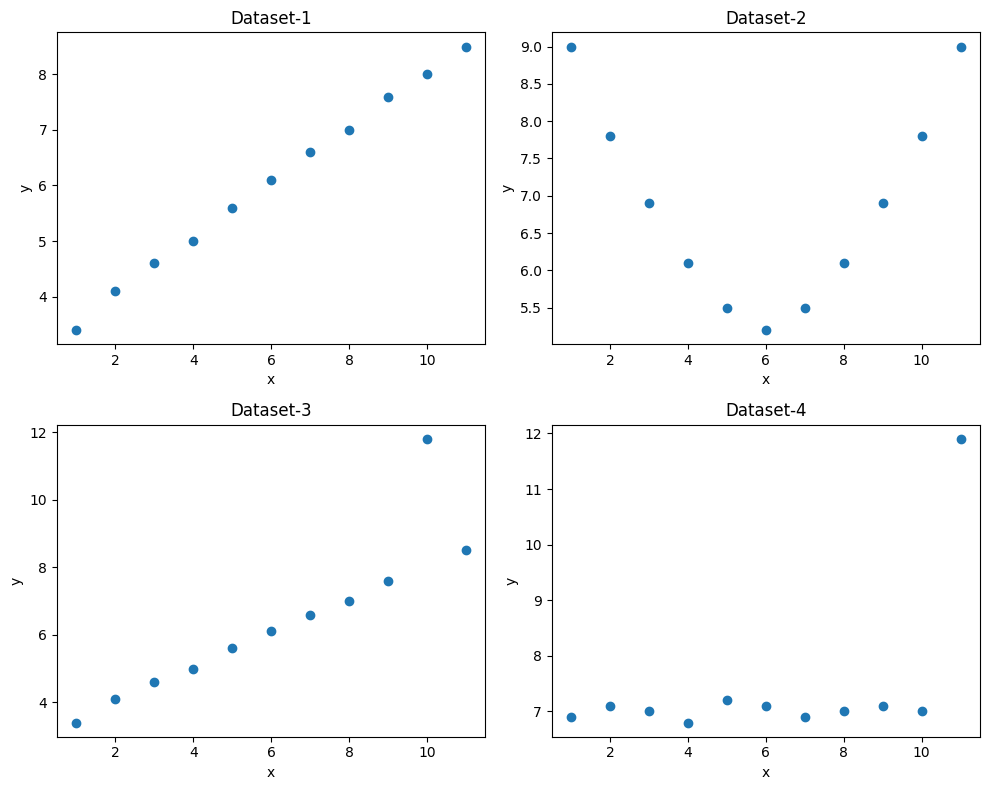

In [9]:
from typing import cast

from matplotlib.axes import Axes


fig , axes = plt.subplots(2,2, figsize=(10,8))
axes = cast(list[Axes] , axes.flatten())
i = 0
for ax , y in zip(axes , datasets) :
    ax.scatter(x , y)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    i += 1
    ax.set_title(f"Dataset-{i}")
fig.tight_layout()

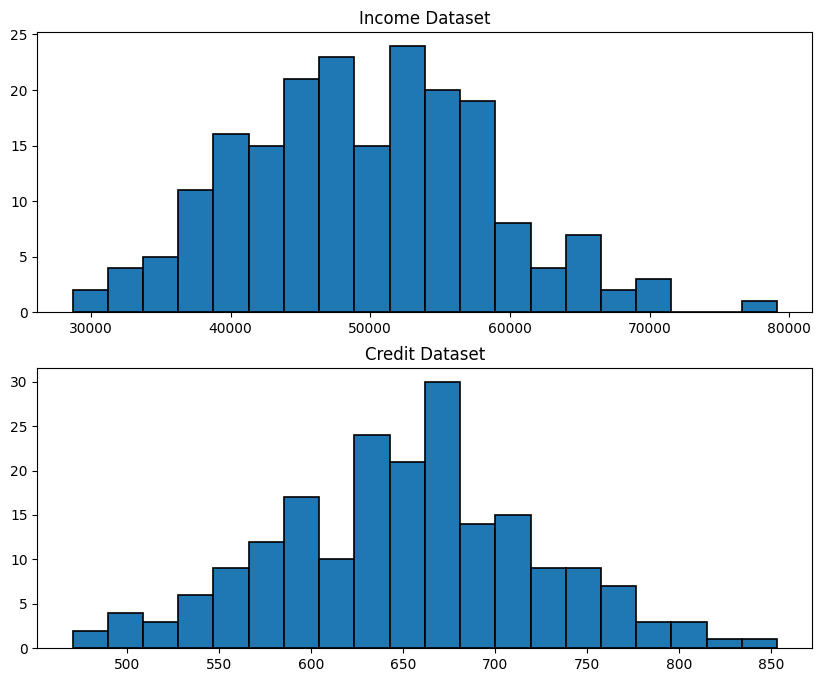

In [14]:
rng = np.random.default_rng(42)
income = rng.normal(50000,10000,200)
credit = rng.normal(650 , 70 , 200)
fix , axes = plt.subplots(2,1,figsize=(10,8))
axes = cast(list[Axes] , axes.flatten())
axes[0].hist(income , 20 , edgecolor='black' , linewidth=1.2)
axes[0].set_title('Income Dataset')
axes[1].hist(credit , 20 , edgecolor='black' , linewidth=1.2)
axes[1].set_title('Credit Dataset')
fig.tight_layout()

Text(0.5, 1.0, 'Leak feature vs default')

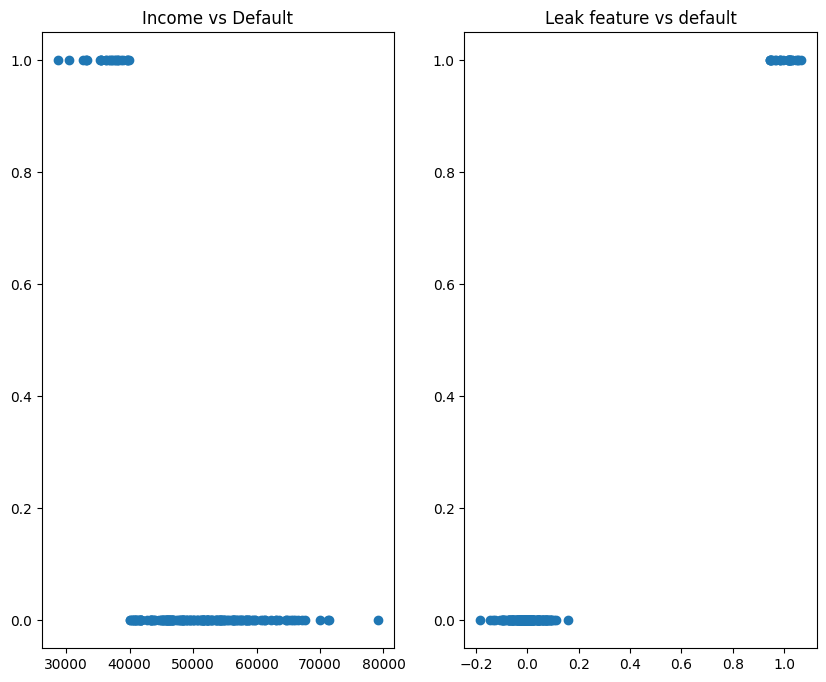

In [19]:
default = (income < 40000).astype(int)
leak_feature = default + rng.normal(0 , 0.05 , 200)
fig , axes = plt.subplots(1,2,figsize=(10,8))
axes[0].scatter(income , default)
axes[0].set_title('Income vs Default')
axes[1].scatter(leak_feature , default)
axes[1].set_title('Leak feature vs default')